# Compare full v3 vs custom no-dyn v3 with bilby

This notebook compares **two environments**:

- `GW` = original / full dynamical tides
- `GW_nodyn` = patched environment with dynamical-tide enhancement removed from the shared `NRTidalv3` phase core

and **three waveform configurations**:

1. `IMRPhenomXP_NRTidalv3`
2. `IMRPhenomXP_NRTidalv3` with `PhenomXHMThresholdMband = 0`
3. `SEOBNRv5_ROM_NRTidalv3`

The goal is to check that switching from `GW` to `GW_nodyn` changes all three configurations in the expected direction.

This notebook uses **bilby** and evaluates waveforms through the BNS **frequency-sequence** source path, so it only computes the frequencies needed for plotting rather than building a full PE-sized FFT grid.

## Notes

- The physical parameters below are taken from your PE-like injection example.
- The PE-like settings are kept where they matter for waveform generation: `minimum_frequency = 10 Hz`, `reference_frequency = 10 Hz`.
- For plotting, the notebook uses a dense user-controlled frequency sequence instead of the full `duration=1024, sampling_frequency=8192` FFT grid.
- For `SEOBNRv5_ROM_NRTidalv3`, the notebook sets

```python
os.environ["LAL_DATA_PATH"] = "/scratch/gpfs/ANDREASB/lalsuite-extra/lalsuite-waveform-data/waveform_data"
```

before waveform generation in each subprocess.

In [1]:
import json
import os
import subprocess
import sys
import tempfile
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

In [2]:
# ---- user-editable paths ----
PYTHON_BY_ENV = {
    "GW": "/home/fy6204/.conda/envs/GW/bin/python",
    "GW_nodyn": "/home/fy6204/.conda/envs/GW_nodyn/bin/python",
}

LAL_DATA_PATH = "/scratch/gpfs/ANDREASB/lalsuite-extra/lalsuite-waveform-data/waveform_data"

# ---- PE-like source / injection parameters ----
INJECTION = {
    "mass_1": 1.8719146682159662,
    "mass_2": 1.6203334784600671,
    "lambda_1": 142.3291063667722,
    "lambda_2": 378.7918706785995,
    "luminosity_distance": 1451.7740835065579,
    "theta_jn": 2.3025723283860398,
    "phase": 3.661366900045683,
    # bilby source-model spin parameterization
    "a_1": 0.0,
    "tilt_1": 0.0,
    "phi_12": 0.0,
    "a_2": 0.0,
    "tilt_2": 0.0,
    "phi_jl": 0.0,
}

# ---- PE-like waveform settings ----
WAVEFORM_BASE = {
    "minimum_frequency": 10.0,
    "reference_frequency": 10.0,
    "maximum_frequency": 2048.0,
}

# plotting / evaluation grid
FMIN = 10.0
FMAX = 2048.0
N_PLOT_FREQS = 40000

FREQUENCIES = np.linspace(FMIN, FMAX, N_PLOT_FREQS)

MODEL_SPECS = [
    {
        "label": "PhenomXP_v3",
        "title": "IMRPhenomXP_NRTidalv3",
        "approximant": "IMRPhenomXP_NRTidalv3",
        "extra_kwargs": {},
        "lal_dict_inserts": {},
        "needs_lal_data_path": False,
    },
    {
        "label": "PhenomXP_v3_HM0",
        "title": "IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0",
        "approximant": "IMRPhenomXP_NRTidalv3",
        "extra_kwargs": {},
        "lal_dict_inserts": {"PhenomXHMThresholdMband": 0},
        "needs_lal_data_path": False,
    },
    {
        "label": "SEOBNRv5_ROM_v3",
        "title": "SEOBNRv5_ROM_NRTidalv3",
        "approximant": "SEOBNRv5_ROM_NRTidalv3",
        "extra_kwargs": {},
        "lal_dict_inserts": {},
        "needs_lal_data_path": True,
    },
]

In [3]:
def _external_waveform_script():
    return r"""
import json
import os
import sys
from pathlib import Path

import numpy as np

payload = json.loads(sys.stdin.read())

if payload.get("lal_data_path"):
    os.environ["LAL_DATA_PATH"] = payload["lal_data_path"]

import bilby
import lalsimulation as lalsim
import lalsimulation.git_version as gv
import lal

freqs = np.asarray(payload["frequencies"], dtype=float)
inj = payload["injection"]
spec = payload["spec"]
base = payload["waveform_base"]

lal_dict = None
if spec.get("lal_dict_inserts"):
    lal_dict = lal.CreateDict()
    for key, value in spec["lal_dict_inserts"].items():
        if key == "PhenomXHMThresholdMband":
            fn = getattr(lalsim, "SimInspiralWaveformParamsInsertPhenomXHMThresholdMband", None)
            if fn is None:
                raise AttributeError("SimInspiralWaveformParamsInsertPhenomXHMThresholdMband not found in this lalsimulation build")
            fn(lal_dict, int(value))
        else:
            raise KeyError(f"Unhandled lal_dict insertion key: {key}")

waveform_kwargs = dict(base)
waveform_kwargs["waveform_approximant"] = spec["approximant"]
waveform_kwargs.update(spec.get("extra_kwargs", {}))
waveform_kwargs["frequencies"] = freqs
waveform_kwargs["catch_waveform_errors"] = False
if lal_dict is not None:
    waveform_kwargs["lal_waveform_dictionary"] = lal_dict

strain = bilby.gw.source.binary_neutron_star_frequency_sequence(
    np.array([0.0]),  # ignored by this source model
    mass_1=inj["mass_1"],
    mass_2=inj["mass_2"],
    luminosity_distance=inj["luminosity_distance"],
    a_1=inj["a_1"],
    tilt_1=inj["tilt_1"],
    phi_12=inj["phi_12"],
    a_2=inj["a_2"],
    tilt_2=inj["tilt_2"],
    phi_jl=inj["phi_jl"],
    lambda_1=inj["lambda_1"],
    lambda_2=inj["lambda_2"],
    theta_jn=inj["theta_jn"],
    phase=inj["phase"],
    **waveform_kwargs,
)

hp = np.asarray(strain["plus"], dtype=np.complex128)
hc = np.asarray(strain["cross"], dtype=np.complex128)

out = {
    "bilby_version": bilby.__version__,
    "lalsimulation_path": lalsim.__file__,
    "lalsimulation_git_id": gv.id,
    "lalsimulation_git_date": gv.date,
    "lalsimulation_git_status": gv.status,
    "frequencies": freqs.tolist(),
    "hp_real": hp.real.tolist(),
    "hp_imag": hp.imag.tolist(),
    "hc_real": hc.real.tolist(),
    "hc_imag": hc.imag.tolist(),
}
print(json.dumps(out))
"""

def run_external_waveform(env_name, python_exe, spec, injection, waveform_base, frequencies, lal_data_path):
    payload = {
        "injection": injection,
        "spec": spec,
        "waveform_base": waveform_base,
        "frequencies": list(map(float, frequencies)),
        "lal_data_path": lal_data_path if spec.get("needs_lal_data_path", False) else None,
    }
    proc = subprocess.run(
        [python_exe, "-c", _external_waveform_script()],
        input=json.dumps(payload),
        text=True,
        capture_output=True,
        check=False,
    )
    if proc.returncode != 0:
        raise RuntimeError(
            f"Waveform generation failed for env={env_name}, model={spec['title']}\n"
            f"STDOUT:\n{proc.stdout}\n\nSTDERR:\n{proc.stderr}"
        )
    out = json.loads(proc.stdout)
    out["frequencies"] = np.asarray(out["frequencies"], dtype=float)
    out["hp"] = np.asarray(out["hp_real"], dtype=float) + 1j * np.asarray(out["hp_imag"], dtype=float)
    out["hc"] = np.asarray(out["hc_real"], dtype=float) + 1j * np.asarray(out["hc_imag"], dtype=float)
    return out

def amp_phase(h):
    amp = np.abs(h)
    phase = np.unwrap(np.angle(h))
    return amp, phase

def align_phase(phase):
    return phase - phase[0]

def safe_log10(x, floor=1e-30):
    return np.log10(np.maximum(x, floor))

In [4]:
results = {}

for spec in MODEL_SPECS:
    results[spec["label"]] = {}
    for env_name, python_exe in PYTHON_BY_ENV.items():
        print(f"Running {spec['title']} in {env_name} ...")
        results[spec["label"]][env_name] = run_external_waveform(
            env_name=env_name,
            python_exe=python_exe,
            spec=spec,
            injection=INJECTION,
            waveform_base=WAVEFORM_BASE,
            frequencies=FREQUENCIES,
            lal_data_path=LAL_DATA_PATH,
        )

print("Done.")

Running IMRPhenomXP_NRTidalv3 in GW ...
Running IMRPhenomXP_NRTidalv3 in GW_nodyn ...
Running IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0 in GW ...
Running IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0 in GW_nodyn ...
Running SEOBNRv5_ROM_NRTidalv3 in GW ...
Running SEOBNRv5_ROM_NRTidalv3 in GW_nodyn ...
Done.


In [5]:
version_rows = []
for spec in MODEL_SPECS:
    for env_name in PYTHON_BY_ENV:
        out = results[spec["label"]][env_name]
        version_rows.append(
            {
                "model": spec["title"],
                "env": env_name,
                "bilby_version": out["bilby_version"],
                "lalsimulation_git_id": out["lalsimulation_git_id"],
                "lalsimulation_git_date": out["lalsimulation_git_date"],
                "lalsimulation_git_status": out["lalsimulation_git_status"],
                "lalsimulation_path": out["lalsimulation_path"],
            }
        )

version_df = pd.DataFrame(version_rows)
version_df

,model,env,bilby_version,lalsimulation_git_id,lalsimulation_git_date,lalsimulation_git_status,lalsimulation_path
0,IMRPhenomXP_NRTidalv3,GW,2.8.0.dev15+g307b15ae1,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,2025-05-20 23:07:03 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW/lib/python3.11/sit...
1,IMRPhenomXP_NRTidalv3,GW_nodyn,2.8.0.dev15+g307b15ae1,1143d786c6e5e770a7d887eec8a980079b4f5b90,2026-03-23 19:45:53 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW_nodyn/lib/python3....
2,IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0,GW,2.8.0.dev15+g307b15ae1,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,2025-05-20 23:07:03 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW/lib/python3.11/sit...
3,IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0,GW_nodyn,2.8.0.dev15+g307b15ae1,1143d786c6e5e770a7d887eec8a980079b4f5b90,2026-03-23 19:45:53 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW_nodyn/lib/python3....
4,SEOBNRv5_ROM_NRTidalv3,GW,2.8.0.dev15+g307b15ae1,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,2025-05-20 23:07:03 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW/lib/python3.11/sit...
5,SEOBNRv5_ROM_NRTidalv3,GW_nodyn,2.8.0.dev15+g307b15ae1,1143d786c6e5e770a7d887eec8a980079b4f5b90,2026-03-23 19:45:53 +0000,CLEAN: All modifications committed,/home/fy6204/.conda/envs/GW_nodyn/lib/python3....


## Per-model comparison: full vs no-dyn

Each block below compares the same waveform configuration between the two environments:

- `GW` (full)
- `GW_nodyn` (patched)

Plots shown:
1. amplitude
2. aligned phase
3. phase difference: `GW_nodyn - GW`
4. fractional amplitude difference: `(A_nodyn - A_full)/A_full`

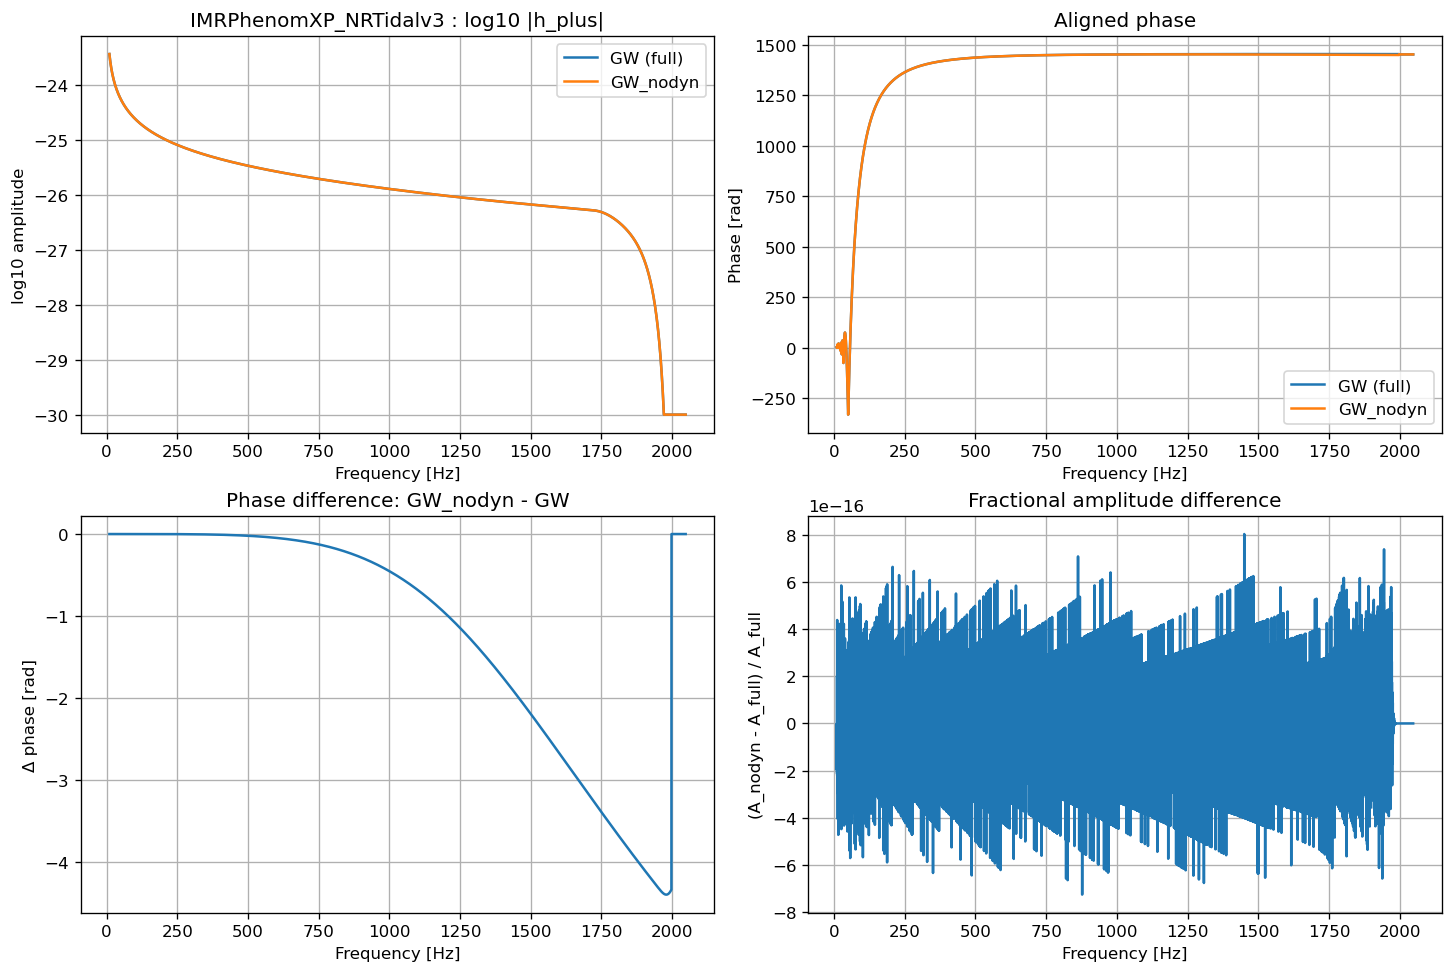

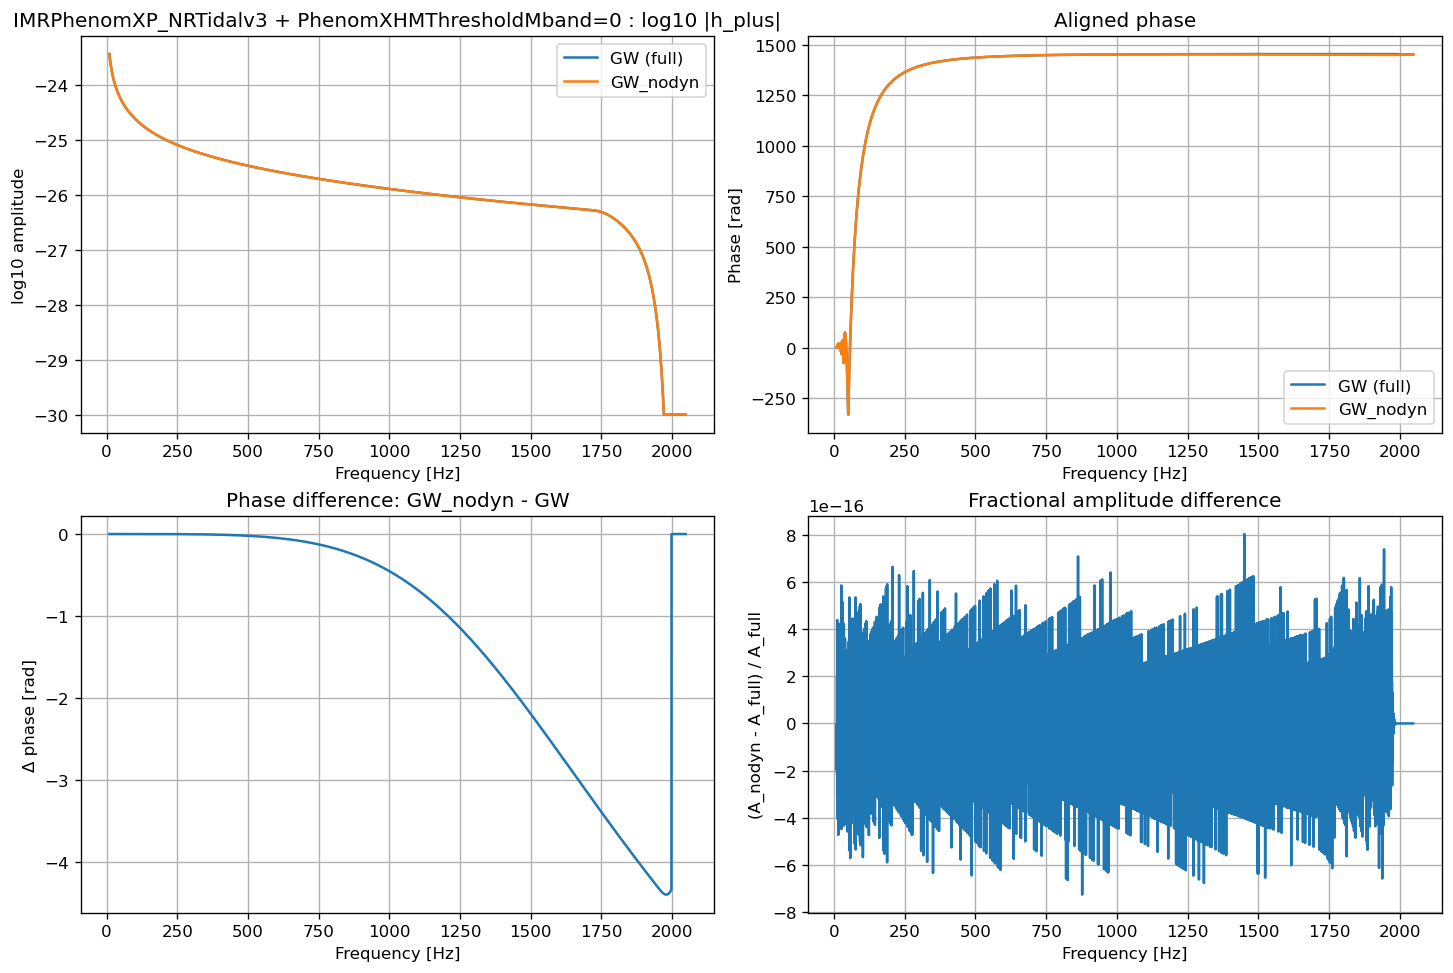

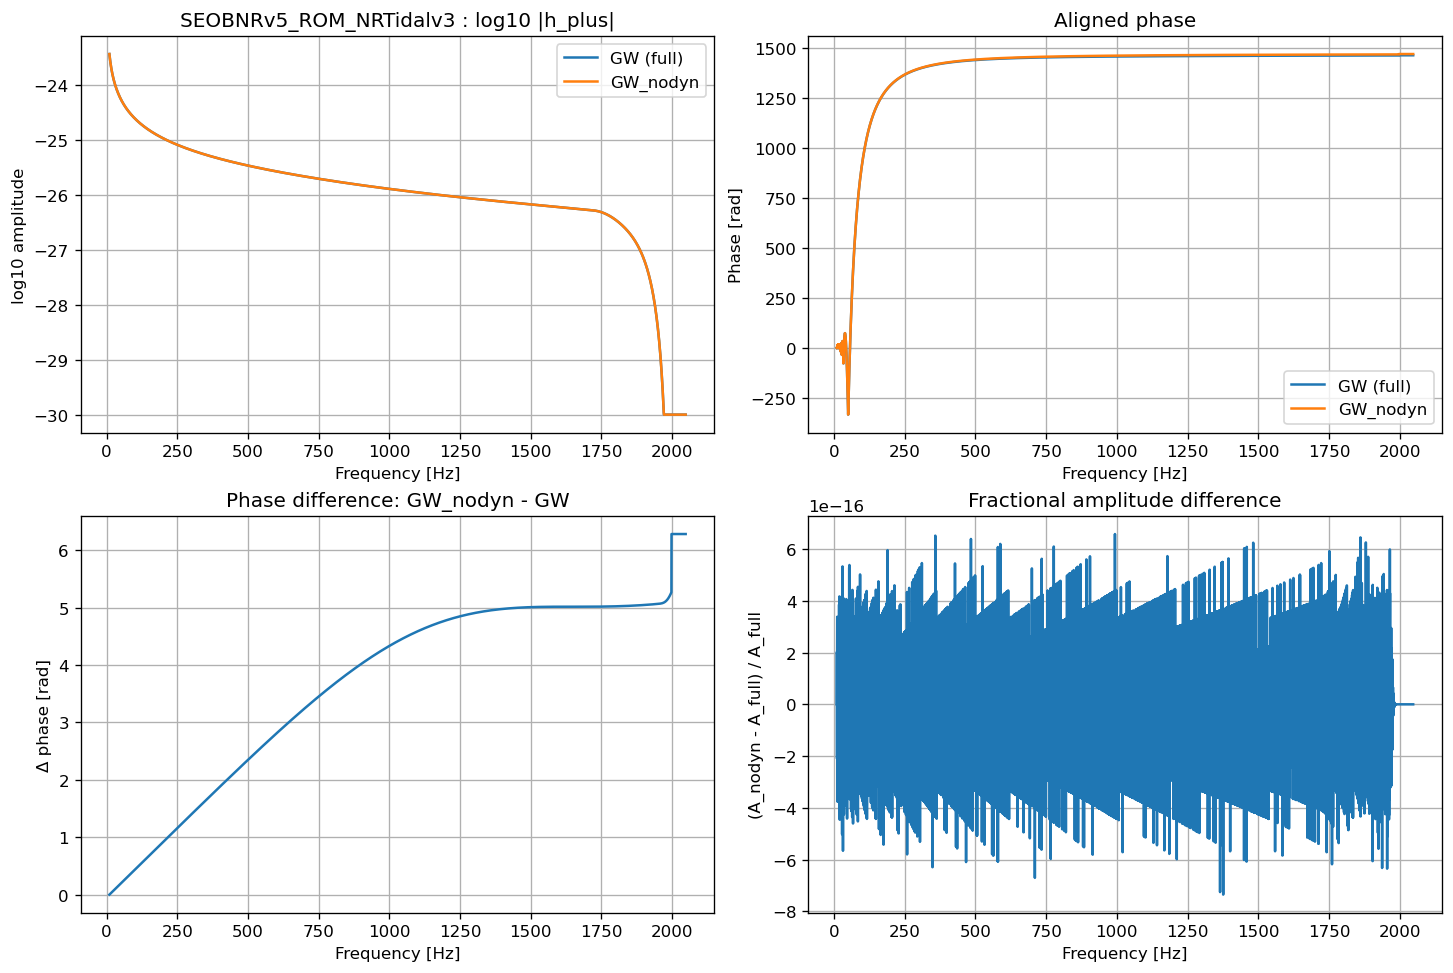

In [6]:
def plot_env_comparison(spec):
    full = results[spec["label"]]["GW"]
    nodyn = results[spec["label"]]["GW_nodyn"]

    f = full["frequencies"]
    assert np.allclose(f, nodyn["frequencies"])

    amp_full, phase_full = amp_phase(full["hp"])
    amp_nodyn, phase_nodyn = amp_phase(nodyn["hp"])

    phase_full_aligned = align_phase(phase_full)
    phase_nodyn_aligned = align_phase(phase_nodyn)
    dphase = phase_nodyn_aligned - phase_full_aligned
    famp = (amp_nodyn - amp_full) / np.maximum(amp_full, 1e-30)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    axes[0, 0].plot(f, safe_log10(amp_full), label="GW (full)")
    axes[0, 0].plot(f, safe_log10(amp_nodyn), label="GW_nodyn")
    axes[0, 0].set_title(spec["title"] + " : log10 |h_plus|")
    axes[0, 0].set_xlabel("Frequency [Hz]")
    axes[0, 0].set_ylabel("log10 amplitude")
    axes[0, 0].legend()

    axes[0, 1].plot(f, phase_full_aligned, label="GW (full)")
    axes[0, 1].plot(f, phase_nodyn_aligned, label="GW_nodyn")
    axes[0, 1].set_title("Aligned phase")
    axes[0, 1].set_xlabel("Frequency [Hz]")
    axes[0, 1].set_ylabel("Phase [rad]")
    axes[0, 1].legend()

    axes[1, 0].plot(f, dphase)
    axes[1, 0].set_title("Phase difference: GW_nodyn - GW")
    axes[1, 0].set_xlabel("Frequency [Hz]")
    axes[1, 0].set_ylabel("Δ phase [rad]")

    axes[1, 1].plot(f, famp)
    axes[1, 1].set_title("Fractional amplitude difference")
    axes[1, 1].set_xlabel("Frequency [Hz]")
    axes[1, 1].set_ylabel("(A_nodyn - A_full) / A_full")

    plt.show()

for spec in MODEL_SPECS:
    plot_env_comparison(spec)

## Zoom into the late inspiral / merger-adjacent regime

This is often the most useful region for visually checking tidal-model differences.

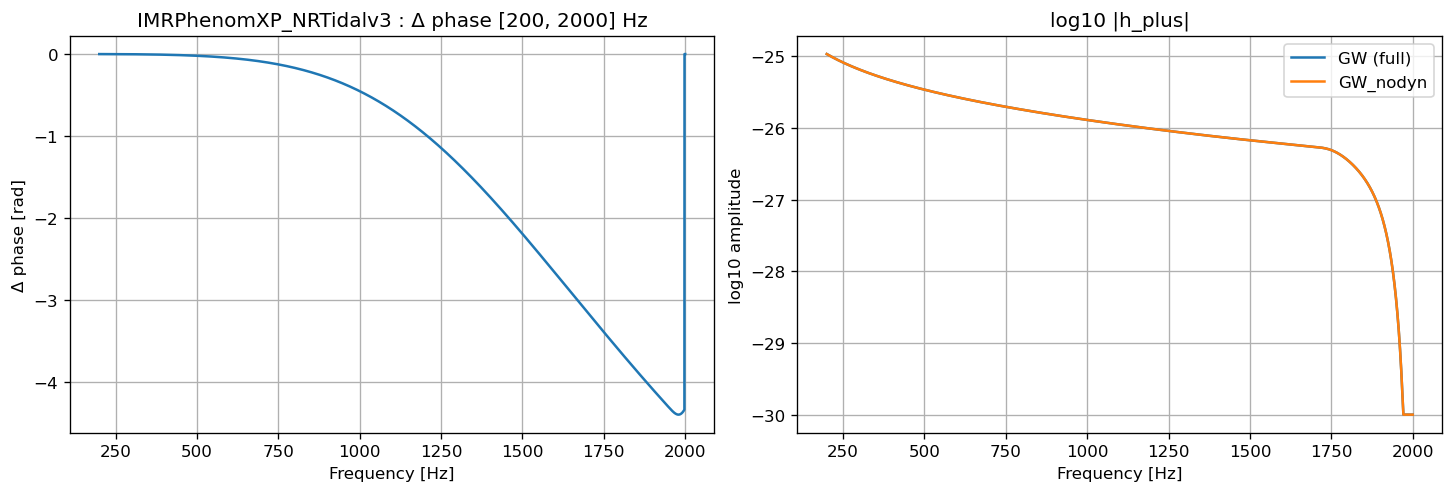

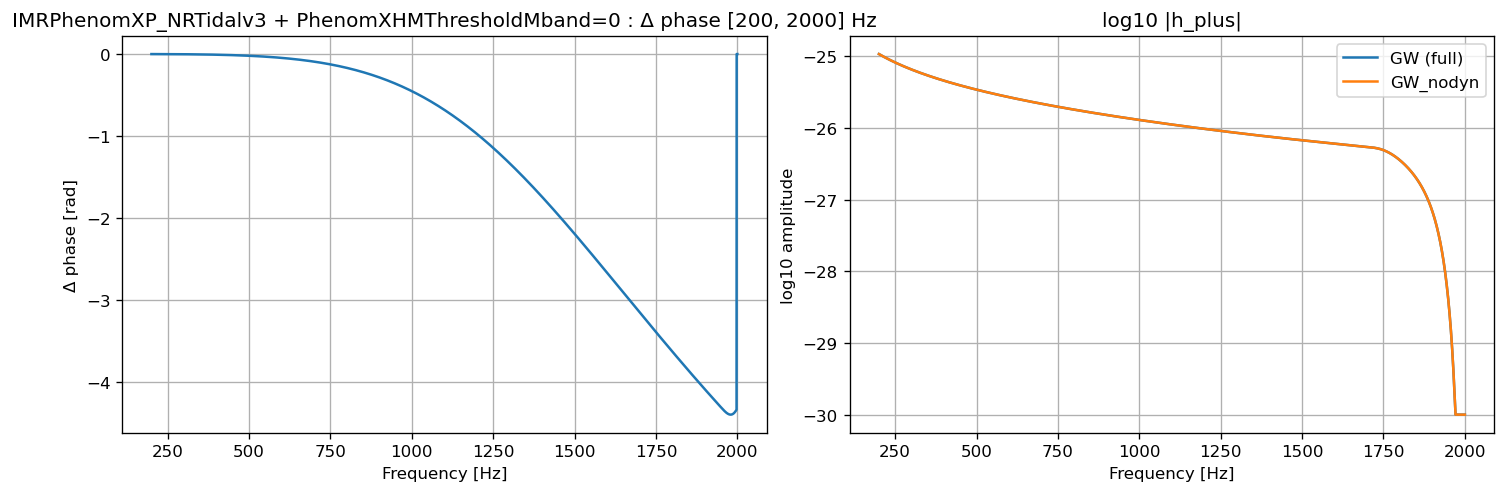

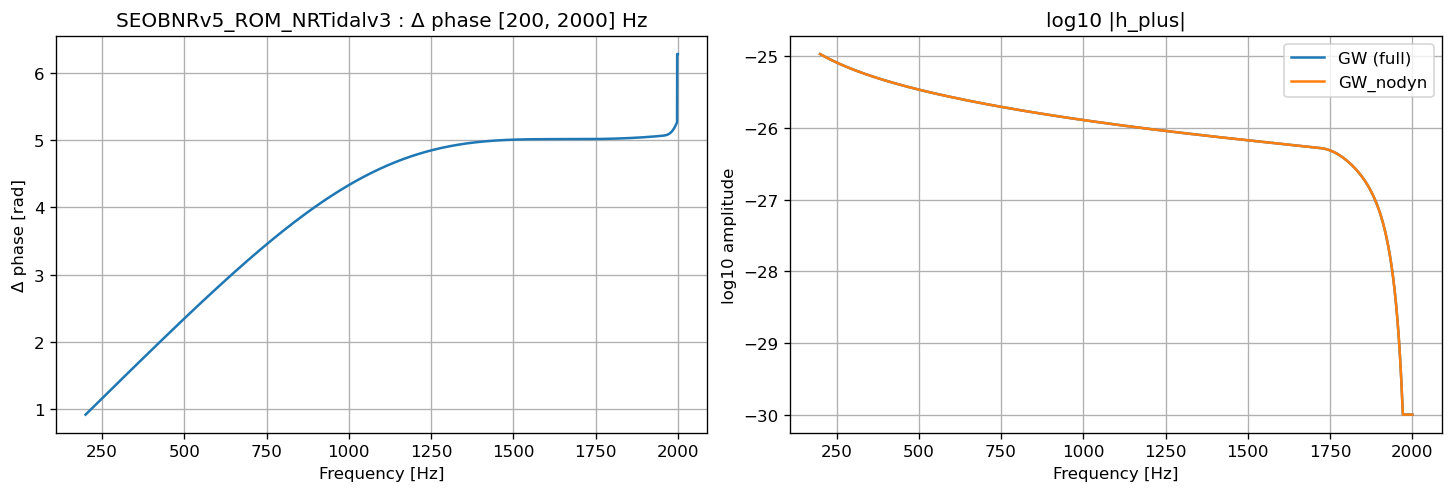

In [7]:
ZOOM_MIN = 200.0
ZOOM_MAX = 2000.0

def plot_zoomed_phase_difference(spec, fmin=ZOOM_MIN, fmax=ZOOM_MAX):
    full = results[spec["label"]]["GW"]
    nodyn = results[spec["label"]]["GW_nodyn"]

    f = full["frequencies"]
    m = (f >= fmin) & (f <= fmax)

    amp_full, phase_full = amp_phase(full["hp"])
    amp_nodyn, phase_nodyn = amp_phase(nodyn["hp"])

    phase_full_aligned = align_phase(phase_full)
    phase_nodyn_aligned = align_phase(phase_nodyn)
    dphase = phase_nodyn_aligned - phase_full_aligned

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    axes[0].plot(f[m], dphase[m])
    axes[0].set_title(spec["title"] + f" : Δ phase [{fmin:.0f}, {fmax:.0f}] Hz")
    axes[0].set_xlabel("Frequency [Hz]")
    axes[0].set_ylabel("Δ phase [rad]")

    axes[1].plot(f[m], safe_log10(amp_full[m]), label="GW (full)")
    axes[1].plot(f[m], safe_log10(amp_nodyn[m]), label="GW_nodyn")
    axes[1].set_title("log10 |h_plus|")
    axes[1].set_xlabel("Frequency [Hz]")
    axes[1].set_ylabel("log10 amplitude")
    axes[1].legend()

    plt.show()

for spec in MODEL_SPECS:
    plot_zoomed_phase_difference(spec)

## Summary metrics

This table is useful for a quick check that `GW_nodyn` is not identical to `GW` for each waveform configuration.

In [8]:
summary_rows = []
for spec in MODEL_SPECS:
    full = results[spec["label"]]["GW"]
    nodyn = results[spec["label"]]["GW_nodyn"]

    f = full["frequencies"]
    amp_full, phase_full = amp_phase(full["hp"])
    amp_nodyn, phase_nodyn = amp_phase(nodyn["hp"])

    phase_full_aligned = align_phase(phase_full)
    phase_nodyn_aligned = align_phase(phase_nodyn)
    dphase = phase_nodyn_aligned - phase_full_aligned
    famp = (amp_nodyn - amp_full) / np.maximum(amp_full, 1e-30)

    band = (f >= 20.0) & (f <= 2000.0)

    summary_rows.append(
        {
            "model": spec["title"],
            "GW_git_id": full["lalsimulation_git_id"],
            "GW_nodyn_git_id": nodyn["lalsimulation_git_id"],
            "max_abs_dphase_20_2000": float(np.max(np.abs(dphase[band]))),
            "rms_dphase_20_2000": float(np.sqrt(np.mean(dphase[band] ** 2))),
            "max_abs_frac_amp_diff_20_2000": float(np.max(np.abs(famp[band]))),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,model,GW_git_id,GW_nodyn_git_id,max_abs_dphase_20_2000,rms_dphase_20_2000,max_abs_frac_amp_diff_20_2000
0,IMRPhenomXP_NRTidalv3,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,1143d786c6e5e770a7d887eec8a980079b4f5b90,4.401949,1.848103,8.044823e-16
1,IMRPhenomXP_NRTidalv3 + PhenomXHMThresholdMband=0,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,1143d786c6e5e770a7d887eec8a980079b4f5b90,4.401949,1.848103,8.044823e-16
2,SEOBNRv5_ROM_NRTidalv3,1338470a6165fb4b4c98bccdd0efe961f05bc8e0,1143d786c6e5e770a7d887eec8a980079b4f5b90,6.283185,3.963088,7.358265e-16


## Overlay the three waveform configurations within each environment

This is optional, but it is useful for checking how the three chosen configurations relate to one another inside the same environment.

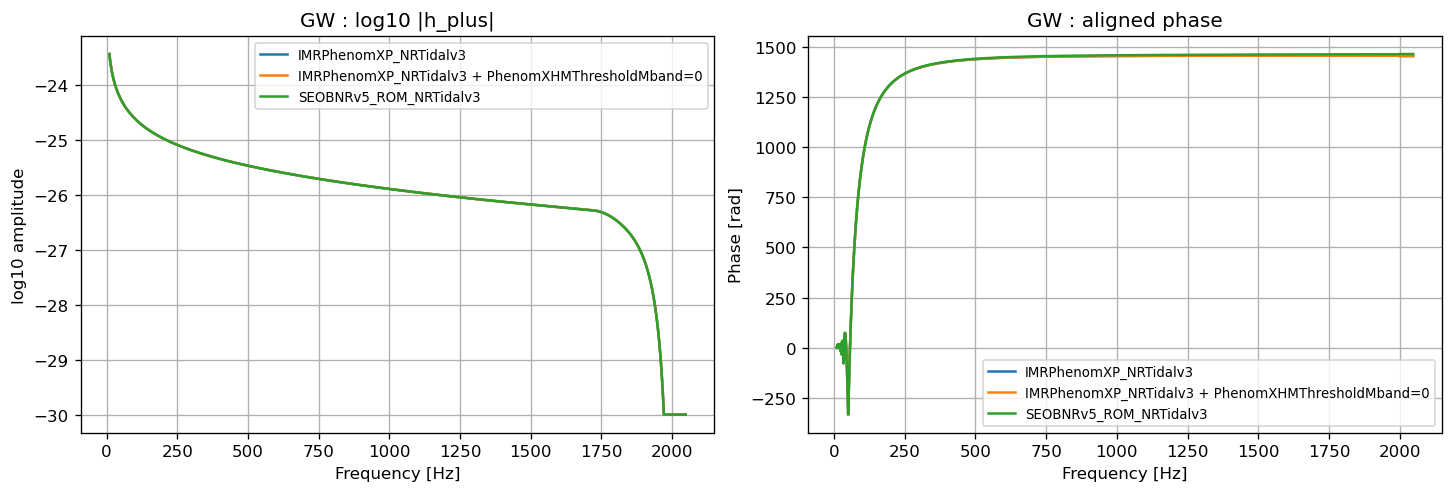

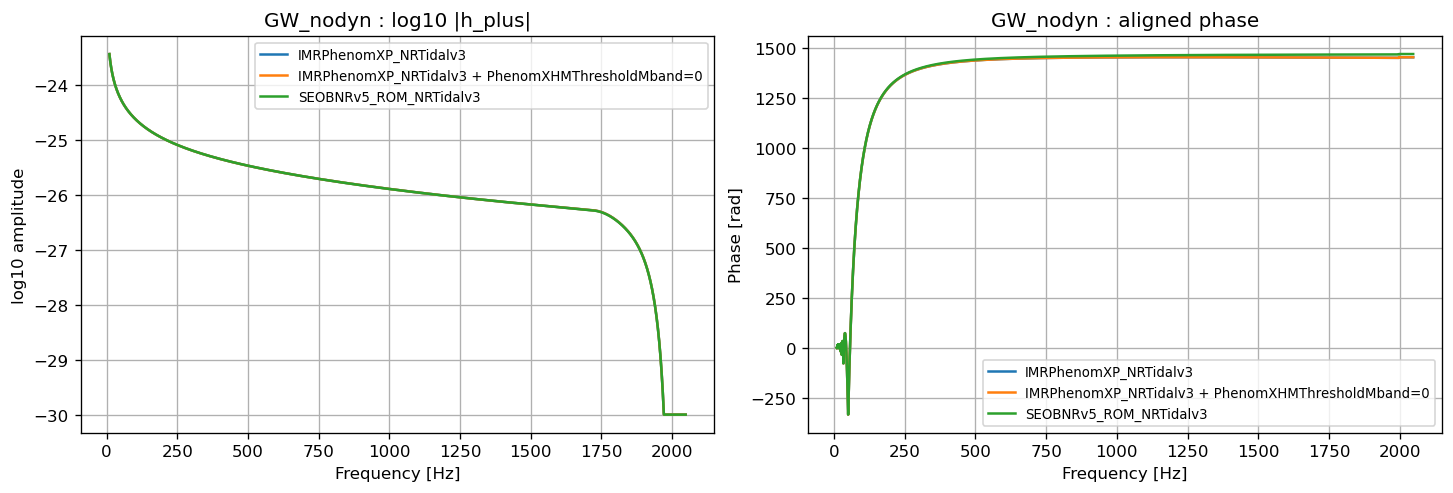

In [9]:
def plot_within_env(env_name, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for spec in MODEL_SPECS:
        out = results[spec["label"]][env_name]
        f = out["frequencies"]
        amp, phase = amp_phase(out["hp"])
        axes[0].plot(f, safe_log10(amp), label=spec["title"])
        axes[1].plot(f, align_phase(phase), label=spec["title"])

    axes[0].set_title(f"{env_name} {title_suffix}: log10 |h_plus|")
    axes[0].set_xlabel("Frequency [Hz]")
    axes[0].set_ylabel("log10 amplitude")
    axes[0].legend(fontsize=8)

    axes[1].set_title(f"{env_name} {title_suffix}: aligned phase")
    axes[1].set_xlabel("Frequency [Hz]")
    axes[1].set_ylabel("Phase [rad]")
    axes[1].legend(fontsize=8)

    plt.show()

plot_within_env("GW")
plot_within_env("GW_nodyn")

## Save compact comparison products

This cell writes small `.npz` files containing the frequency grid and the `h_plus` waveform for each environment/model pair. That can be useful if you later want to make a separate plotting notebook.

In [10]:
OUTPUT_DIR = Path("waveform_compare_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

for spec in MODEL_SPECS:
    for env_name in PYTHON_BY_ENV:
        out = results[spec["label"]][env_name]
        np.savez(
            OUTPUT_DIR / f"{env_name}_{spec['label']}.npz",
            frequencies=out["frequencies"],
            hp=out["hp"],
            hc=out["hc"],
            bilby_version=out["bilby_version"],
            lalsimulation_git_id=out["lalsimulation_git_id"],
            lalsimulation_git_date=out["lalsimulation_git_date"],
            lalsimulation_git_status=out["lalsimulation_git_status"],
        )

print(f"Saved outputs in: {OUTPUT_DIR.resolve()}")

Saved outputs in: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/waveform_compare_outputs


## Interpretation guide

What you want to see:

- the `lalsimulation_git_id` in `GW` and `GW_nodyn` should be different;
- for each of the three waveform configurations, the `GW_nodyn - GW` phase difference should be visibly nonzero over at least part of the late-inspiral / high-frequency region;
- if one configuration looks numerically identical between the two environments, that is evidence that your patch is not affecting that configuration the way you expect.

This notebook is meant as a **diagnostic comparison notebook**, not as a PE notebook.